# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

<br>

<br>

**Analysis prompt**

 * **Sky Reconstruction Efficiency:**
     - true-IROS slices
     - fitted sources params (residues WRT true)
     - CFR between true and IROS sky images
 
 * **Spectroscopic Capabilities**
     - ScoX-1 spectrum reconstruction (or at least the interesting part for state change)
 
 * **BKG Smoothing**

<br>

**Discussions prompt**

 * **Inter-px grid resolution:**
    - sources parameters estimation
    - procedure computational cost
    - CFR with instr./on-fly errors

 * **Double-Camera Enhancement:**
    - improved localisation with Unit fine dirs
    - CFR with GW170817 sky uncertainty box of $~31 \text{deg}^{2}$ at 90% prob --during measurements-- (transient obs alarm and sky area uncertainty)
 
 * **Energy bands impact and limitations**
    - instrumental effects modelling
    - source template modelling
    - source optimisation routine
    - **NOTE:** these are content for a second analytic IROS paper (**analyses and tests already done!**)
        * multi-energy bands IROS reconstruction
        * source template with ebands components
        * energy-dependent instr. effects modelling (supported by mock sources tests)

<br>

<br>

<br>

In [ ]:
from pathlib import Path
from typing import Any, Callable, NamedTuple

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds
from darksun.show import DSPlot, export_pltparams
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.benchmarking import dict2df

from IROSrec.handle import config_dirpaths

# ds.show.set_figures_darkbkg()

In [2]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Extracts the catalogue sources angular coords in [deg]
    along the fine and coarse direction respectively.
    """
    angles_x, angles_y = [], []
    loop = tqdm(log.log['ID'])
    for sourceID in loop:
        loop.set_description(f'Analysing {sourceID.upper()}')
        anglex, angley = (
            ds.source_angular_coords(sourceID, catalogue, sdl, camera)
            if sourceID in catalogue.DLdata['ID']
            else (np.nan, np.nan)
        )
        angles_x.append(anglex)
        angles_y.append(angley)

    return map(np.array, (angles_x, angles_y))

def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin], along
    the fine and coarse direction respectively.
    """
    angles_x, angles_y = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    res_x, res_y = (
        60 * (np.array(log.log['angle_x']) - angles_x),
        60 * (np.array(log.log['angle_y']) - angles_y),
    )
    return res_x, res_y

def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = False,
) -> NDArray:
    """
    Extracts the catalogue sources fluences.
    """
    fluences: list[float] = []
    loop = tqdm(log.log['ID'])
    for sourceID in loop:
        loop.set_description(f'Analysing {sourceID.upper()}')
        fluence = (
            ds.source_fluence(sourceID, catalogue, sdl, camera, verbose)
            if sourceID in catalogue.DLdata['ID']
            else np.nan
        )
        fluences.append(fluence)
        
    return np.array(fluences)

In [3]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag


MASK_FITS: str = "mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

RUN_ID: str = 'GC_rec_1ks_2-50keV'

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

E_min, E_max = 2.0, 50.0  # [keV]

UPS_X: int = 2
UPS_Y: int = 1

PSFY: bool = config_psfy_flag(DATASET)

In [4]:
# load filepaths
def config_savedata_to() -> str:
    """Generates the path to directory for saving files."""
    paths = [
        '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/IROS_paper',
        '/mnt/d/PhD_AASS/Coding/Images_fits/IROS_paper',
    ]
    out = next((p for p in paths if Path(p).is_dir()), None)
    if out is None: raise ValueError('A0 ndo sei finit*?')
    return out

MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET], E_min=E_min, E_max=E_max)
catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, logB = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


<br>

<br>

<br>

<br>

## <center>**Sky Reconstruction Efficiency**<center>

### **Benchmark Tables**

In [5]:
# Tables with IROS reconstruction data
import re

class CameraUnitMap(NamedTuple):
    common: NDArray
    unique: NDArray
    idx_a: NDArray
    idx_b: NDArray

def get_srcmap_for_unit(
    srcA: list[str],
    srcB: list[str],
    uniqueIDs: bool = True,
) -> CameraUnitMap:
    """
    Finds common sources in LEM-X Unit IROS reconstruction from detected sources IDs.
    Returns the sorted, unique src IDs that are in both input lists, and the index map.
    """
    srcA_, srcB_ = map(np.array, (srcA, srcB))
    common, idx_a, idx_b = np.intersect1d(
        srcA_, srcB_, assume_unique=uniqueIDs, return_indices=True,
    )
    unique = np.setxor1d(srcA_, srcB_, assume_unique=uniqueIDs)
    return CameraUnitMap(common, unique, idx_a, idx_b)

def df2TeXtab(
    df: pd.DataFrame,
    save_to: str | Path | None = None,
    overwrite: bool = False,
    **tex_kws: Any,
) -> str:
    """
    Generates a LaTeX table from input dataframe and saves it.
    """
    def adjust_Tabfrmt(txt: str) -> str:
        # insert \hline instead of rules (journal guidelines)
        for rule in ('toprule', 'midrule', 'bottomrule'):
            txt = txt.replace(rule, 'hline')
        # shift caption and label at the end (journal guidelines)
        pattern = r"(\\begin\{table\}.*?)(\\caption\{.*?\})\s*(\\label\{.*?\})\s*(\\begin\{tabular\}.*?\\end\{tabular\})"
        replacement = r"\1\4\n\2\n\3"
        txt = re.sub(pattern, replacement, txt, flags=re.DOTALL)
        # convert to onecolumn
        txt = txt.replace('table', 'table*')
        return txt

    tab = df.to_latex(index=False, **tex_kws)
    tab = adjust_Tabfrmt(tab)

    if save_to is not None:
        if Path(save_to).exists() and not overwrite:
            print('Table already saved!')
            return tab
        with open(save_to, "w", encoding="utf-8") as f:
            f.write(tab)
    
    return tab

In [6]:
def get_singlecam_table(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    idx_map: NDArray | None = None,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    ids = np.array([src.upper() for src in log.log['ID']])
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log, catalogue, sdl, camera,
    )
    fluence = np.array(log.log['fluence'])
    true_cts = extract_catalogue_fluences(log, catalogue, sdl, camera)
    transf: Callable[[NDArray], NDArray] = lambda x: x[idx_map] if idx_map is not None else x
    dmap = {
        log.name: {
            'Source': transf(ids),
            'thetaX [deg]': transf(np.array(log.log['angle_x'])),
            'DthetaX [arcmin]': transf(theta_res_x),
            'thetaY [deg]': transf(np.array(log.log['angle_y'])),
            'DthetaY [arcmin]': transf(theta_res_y),
            'DCounts [sigma]': transf((fluence - true_cts) / np.sqrt(true_cts)),
            'DCounts [%]': transf(fluence * 100 / true_cts),
            'SNR': transf(np.array(log.log['snr'])),
        }
    }
    df = dict2df(dmap).dropna()
    return df

def get_unitcam_table(
    data_camA: pd.DataFrame,
    data_camB: pd.DataFrame,
    unitmap: CameraUnitMap,
    compose_with: str | Callable[[NDArray, NDArray], NDArray] = 'quadsum',
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS at LEM-X Unit level.
    """
    if isinstance(compose_with, str):
        match compose_with:
            case 'quadsum':
                compose: Callable = lambda a, b: np.sqrt(a ** 2 + b ** 2)
            case 'max':
                compose: Callable = lambda a, b: np.concat((a[:, None], b[:, None]), axis=1).max(axis=1)
            case _:
                raise ValueError('Selected `compose_with` operation not available.')
    elif callable(compose_with):
        compose: Callable = compose_with
    else:
        raise ValueError('Invalid `compose_with` format.')

    dmap = {
        'Source': np.array(data_camA.CAM1A['Source'])[unitmap.idx_a],
        'thetaX_A [deg]': np.array(data_camA.CAM1A['thetaX [deg]'])[unitmap.idx_a],
        'thetaX_B [deg]': np.array(data_camB.CAM1B['thetaX [deg]'])[unitmap.idx_b],
        'DthetaX [arcmin]': compose(
            np.array(data_camA.CAM1A['DthetaX [arcmin]'])[unitmap.idx_a],
            np.array(data_camB.CAM1B['DthetaX [arcmin]'])[unitmap.idx_b],
        ),
        'SNR': compose(
            np.array(data_camA.CAM1A['SNR'])[unitmap.idx_a],
            np.array(data_camB.CAM1B['SNR'])[unitmap.idx_b],
        ),
    }
    return pd.DataFrame(dmap)

def sort_by(df: pd.DataFrame, key: str, **kwargs: Any) -> pd.DataFrame:
    """Sort DataFrame wrt input column key."""
    by = (df.columns[0][0], key) if isinstance(df.columns[0], tuple) else key
    return df.sort_values(by=[by], ascending=False, ignore_index=True, **kwargs)

In [7]:
ds.pixels_angular_resolution(wfm)
cu_map = get_srcmap_for_unit(logA.log['ID'], logB.log['ID'])

# Table - CAMERA A
data_camA = get_singlecam_table(logA, catA, sdlA, wfm)

tab = df2TeXtab(
    sort_by(data_camA, 'SNR'), f'{OUT_RESULTS_PATH}/texTable_{ID_CAMERA_A.upper()}_results.tex', overwrite=True,
    label='Table1', caption='Testing $`to\\_latex`$ fn.', float_format="%.3f", column_format='l' + 'c' * (len(data_camA.columns) - 1),
    multicolumn_format="c",
)

# Table - CAMERA B
data_camB = get_singlecam_table(logB, catB, sdlB, wfm)

tab = df2TeXtab(
    sort_by(data_camB, 'SNR'), f'{OUT_RESULTS_PATH}/texTable_{ID_CAMERA_B.upper()}_results.tex', overwrite=True,
    label='Table2', caption='Testing $`to\\_latex`$ fn.', float_format="%.3f", column_format='l' + 'c' * (len(data_camB.columns) - 1),
    multicolumn_format="c",
)


Pixel angular resolution at upscaling (x, y): (2, 1)
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



Analysing GX5-1:   5%|▍         | 1/21 [00:18<06:19, 18.97s/it]

## USING BULK MASK with 1.5 mm cover ##


Analysing LEMX-CAM1BS1: 100%|██████████| 20/20 [00:21<00:00,  1.06s/it]  


In [8]:
data_unit = get_unitcam_table(data_camA, data_camB, cu_map)

tab = df2TeXtab(
    sort_by(data_unit, 'SNR'), f'{OUT_RESULTS_PATH}/texTable_Unit_results.tex', overwrite=True,
    label='Table3', caption='Testing $`to\\_latex`$ fn.', float_format="%.3f", column_format='c' * len(data_unit.columns),
)

### **Sky-field Decoding**

In [9]:
# Sky reconstruction efficiency: pre/post IROS

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes

from regions import Regions, PixCoord, TextPixelRegion, RegionVisual


def open_ImageHDU(filepath: str, ext: int = 1) -> tuple[NDArray, WCS | None]:
    """
    Opens FITS file and extracts the chosen Image.
    Returns the Image HDU and the associated WCS.
    """
    with fits.open(filepath) as hdu:
        img_hdu = hdu[ext]
        img = img_hdu.data
        try:
            wcs = WCS(img_hdu.header)
        except (KeyError, ValueError) as e:
            print(f'Error: {e}. WCS not extractable.')
            wcs = None
    
    return img, wcs


def show_composed_skymap(
    image: NDArray,
    reg: Regions,
    wcs: WCS,
    ticks_spacing: int | float = 20,
    txt_offset: tuple[int, int] = (5, 20),
    txt_visual: dict[str, Any] | None = None,
    save_to: str | None = None,
) -> None:
    """
    Plots the LEM-X Unit composed skymap with reconstructed sources from IROS.\n
    CFR w: [composed GalCentre](https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Plot_IROS_Composed_Image.ipynb).
    """
    PLOTPARAMS = export_pltparams()
    PLOTPARAMS['ticklabel_fs'] = 5
    KWS = {
        'cmap': 'viridis', 'origin': 'lower', 'interpolation': 'none',
    }

    fig = plt.figure(dpi=250)
    wcsax = WCSAxes(fig, 111, wcs=wcs)
    fig.add_axes(wcsax)

    # config ticks
    for crd in wcsax.coords:
        crd.set_ticklabel_visible(False)
        crd.set_ticks_visible(False)

    # confing `galactic` overlay
    overlay = wcsax.get_coords_overlay('galactic')
    overlay.grid(
        visible=True, color=PLOTPARAMS['grid_color'], linestyle=PLOTPARAMS['grid_ls'],
        linewidth=0.8 * PLOTPARAMS['grid_lw'], alpha=0.2,
    )
    axs_lbl = ('galactic longitude [deg]', 'galactic latitude [deg]')
    for lbl, ovl in zip(axs_lbl, overlay):
        ovl.set_axislabel(lbl, fontsize=1.1 * PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
        ovl.set_ticklabel(fontsize=PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
        ovl.set_major_formatter('d')
        ovl.set_ticks(spacing=ticks_spacing * u.degree)
        ovl.tick_params(which='both', direction='in', width=1.5, length=3 if 'major' else 2)
    
    img = wcsax.imshow(image, **KWS)
    # cbar = fig.colorbar(
    #     img, ax=wcsax, location='bottom', shrink=0.5 * PLOTPARAMS['cbar_shrink'],
    #     pad=PLOTPARAMS[f'cbar_pad_right'],
    # )
    # cbar.ax.tick_params(labelsize=PLOTPARAMS['ticklabel_fs'])
    # cbar.set_label(
    #     'SNR', fontsize=1.1 * PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    # )

    # insert region info
    txt_visual_ = txt_visual or {}
    visual = RegionVisual(txt_visual_)
    delta = PixCoord(*txt_offset)
    for src in reg:
        text = src.meta['text']
        pixel_region = src.to_pixel(wcs)
        pixel_region.plot(ax=wcsax)
        txt = TextPixelRegion(center=pixel_region.center + delta, text=text, visual=visual)
        txt.plot(ax=wcsax)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

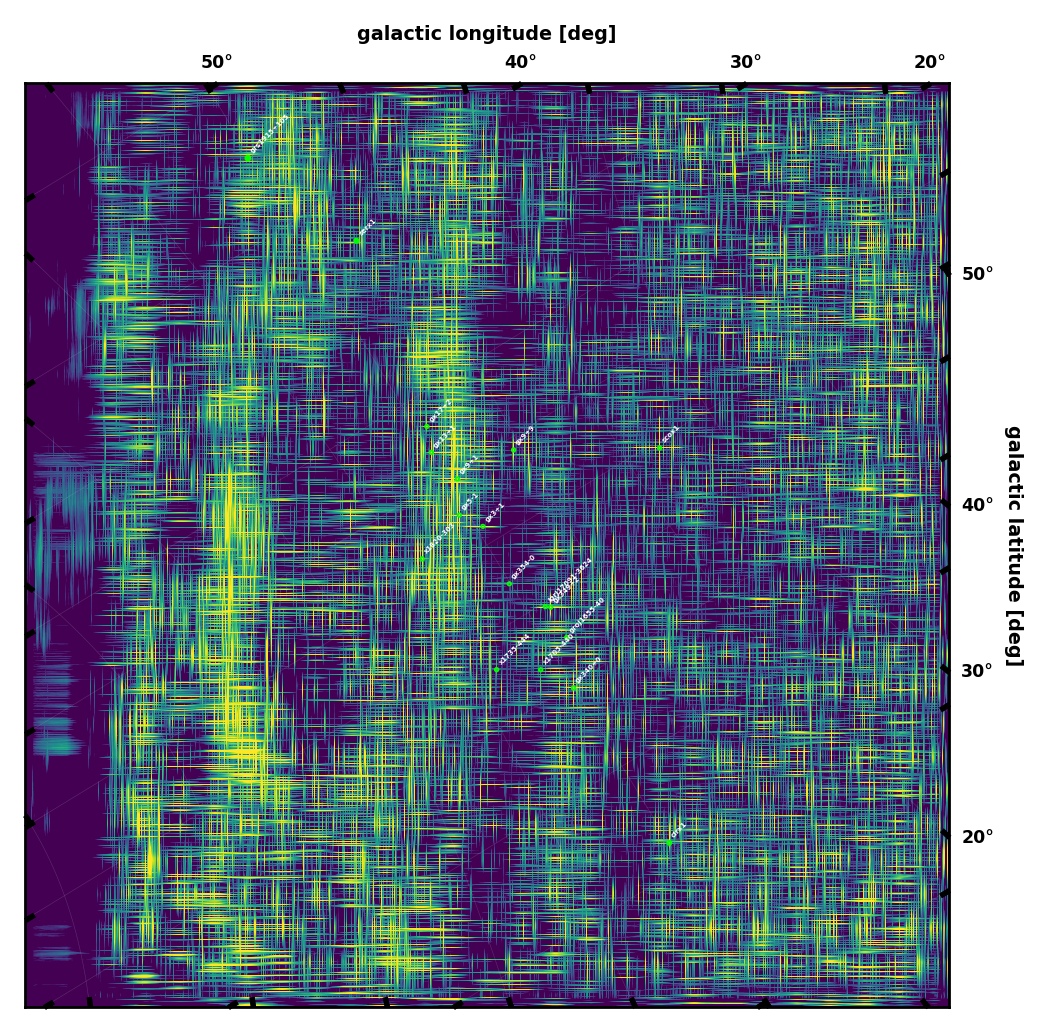

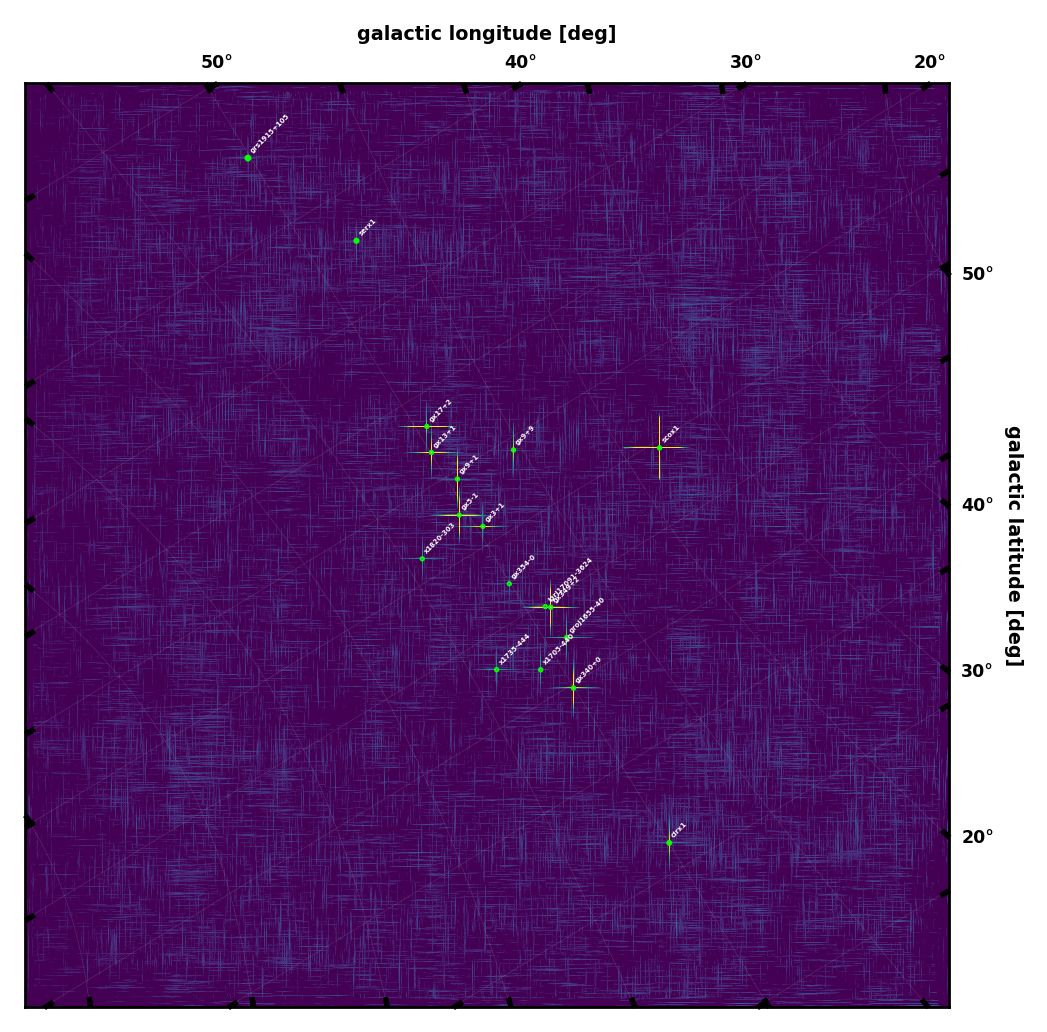

In [22]:
compIROS_true_path = f"{SAVE_PATH}/COMPOSED_sky_SIMUL_CAM1A_CAM1B.fits"
compIROS_out_path = f"{SAVE_PATH}/COMPOSED_OUTsky_IROS_CAM1A_CAM1B.fits"
reg_file_path = f"{SAVE_PATH}/OUTregionfile_IROS_CAM1B.reg"

cu_map = get_srcmap_for_unit(logA.log['ID'], logB.log['ID'])

true_comp, wcs = open_ImageHDU(compIROS_true_path, ext=2)
out_comp, _ = open_ImageHDU(compIROS_out_path, ext=2)
reg = np.array(Regions.read(reg_file_path, format='ds9'))[cu_map.idx_b]

transf: Callable = lambda x: np.pow(np.clip(x, a_min=0.5, a_max=20), 0.75)

KWS_comp = {
    'ticks_spacing': 10,
    'txt_visual': {'textangle': 45, 'color': 'white', 'fontsize': 2},
}

show_composed_skymap(
    image=transf(true_comp),
    reg=reg,
    wcs=wcs,
    save_to=f'{OUT_RESULTS_PATH}/composed_TRUESKY.pdf',
    **KWS_comp,
)
show_composed_skymap(
    image=transf(out_comp),
    reg=reg,
    wcs=wcs,
    save_to=f'{OUT_RESULTS_PATH}/composed_OUTSKY.pdf',
    **KWS_comp,
)

In [13]:
# from astropy.nddata import Cutout2D
# from astropy.coordinates import SkyCoord

# IDX: int = 0   # scox-1

# POS: tuple[int, int] = (logA.log['ra'][IDX], logA.log['dec'][IDX])
# SIZE: tuple[int, int] = (1000, 1000)

# # n, m = img.shape
# # img_ = transf(img)[: int(0.9 * n), int(0.1 * m) : int(0.9 * m)]

# cutout = Cutout2D(img, SkyCoord(ra=POS[0], dec=POS[1], frame='fk5', unit='deg'), SIZE, wcs=wcs)

# show_composed_skymap(
#     image=transf(cutout.data),
#     reg=reg,
#     wcs=cutout.wcs,
#     spacing=5,
#     save_to=f'{OUT_RESULTS_PATH}/test_comp_cutout.pdf'
# )

Analysing LEMX-CAM1BS1: 100%|██████████| 20/20 [00:00<00:00, 173.75it/s]


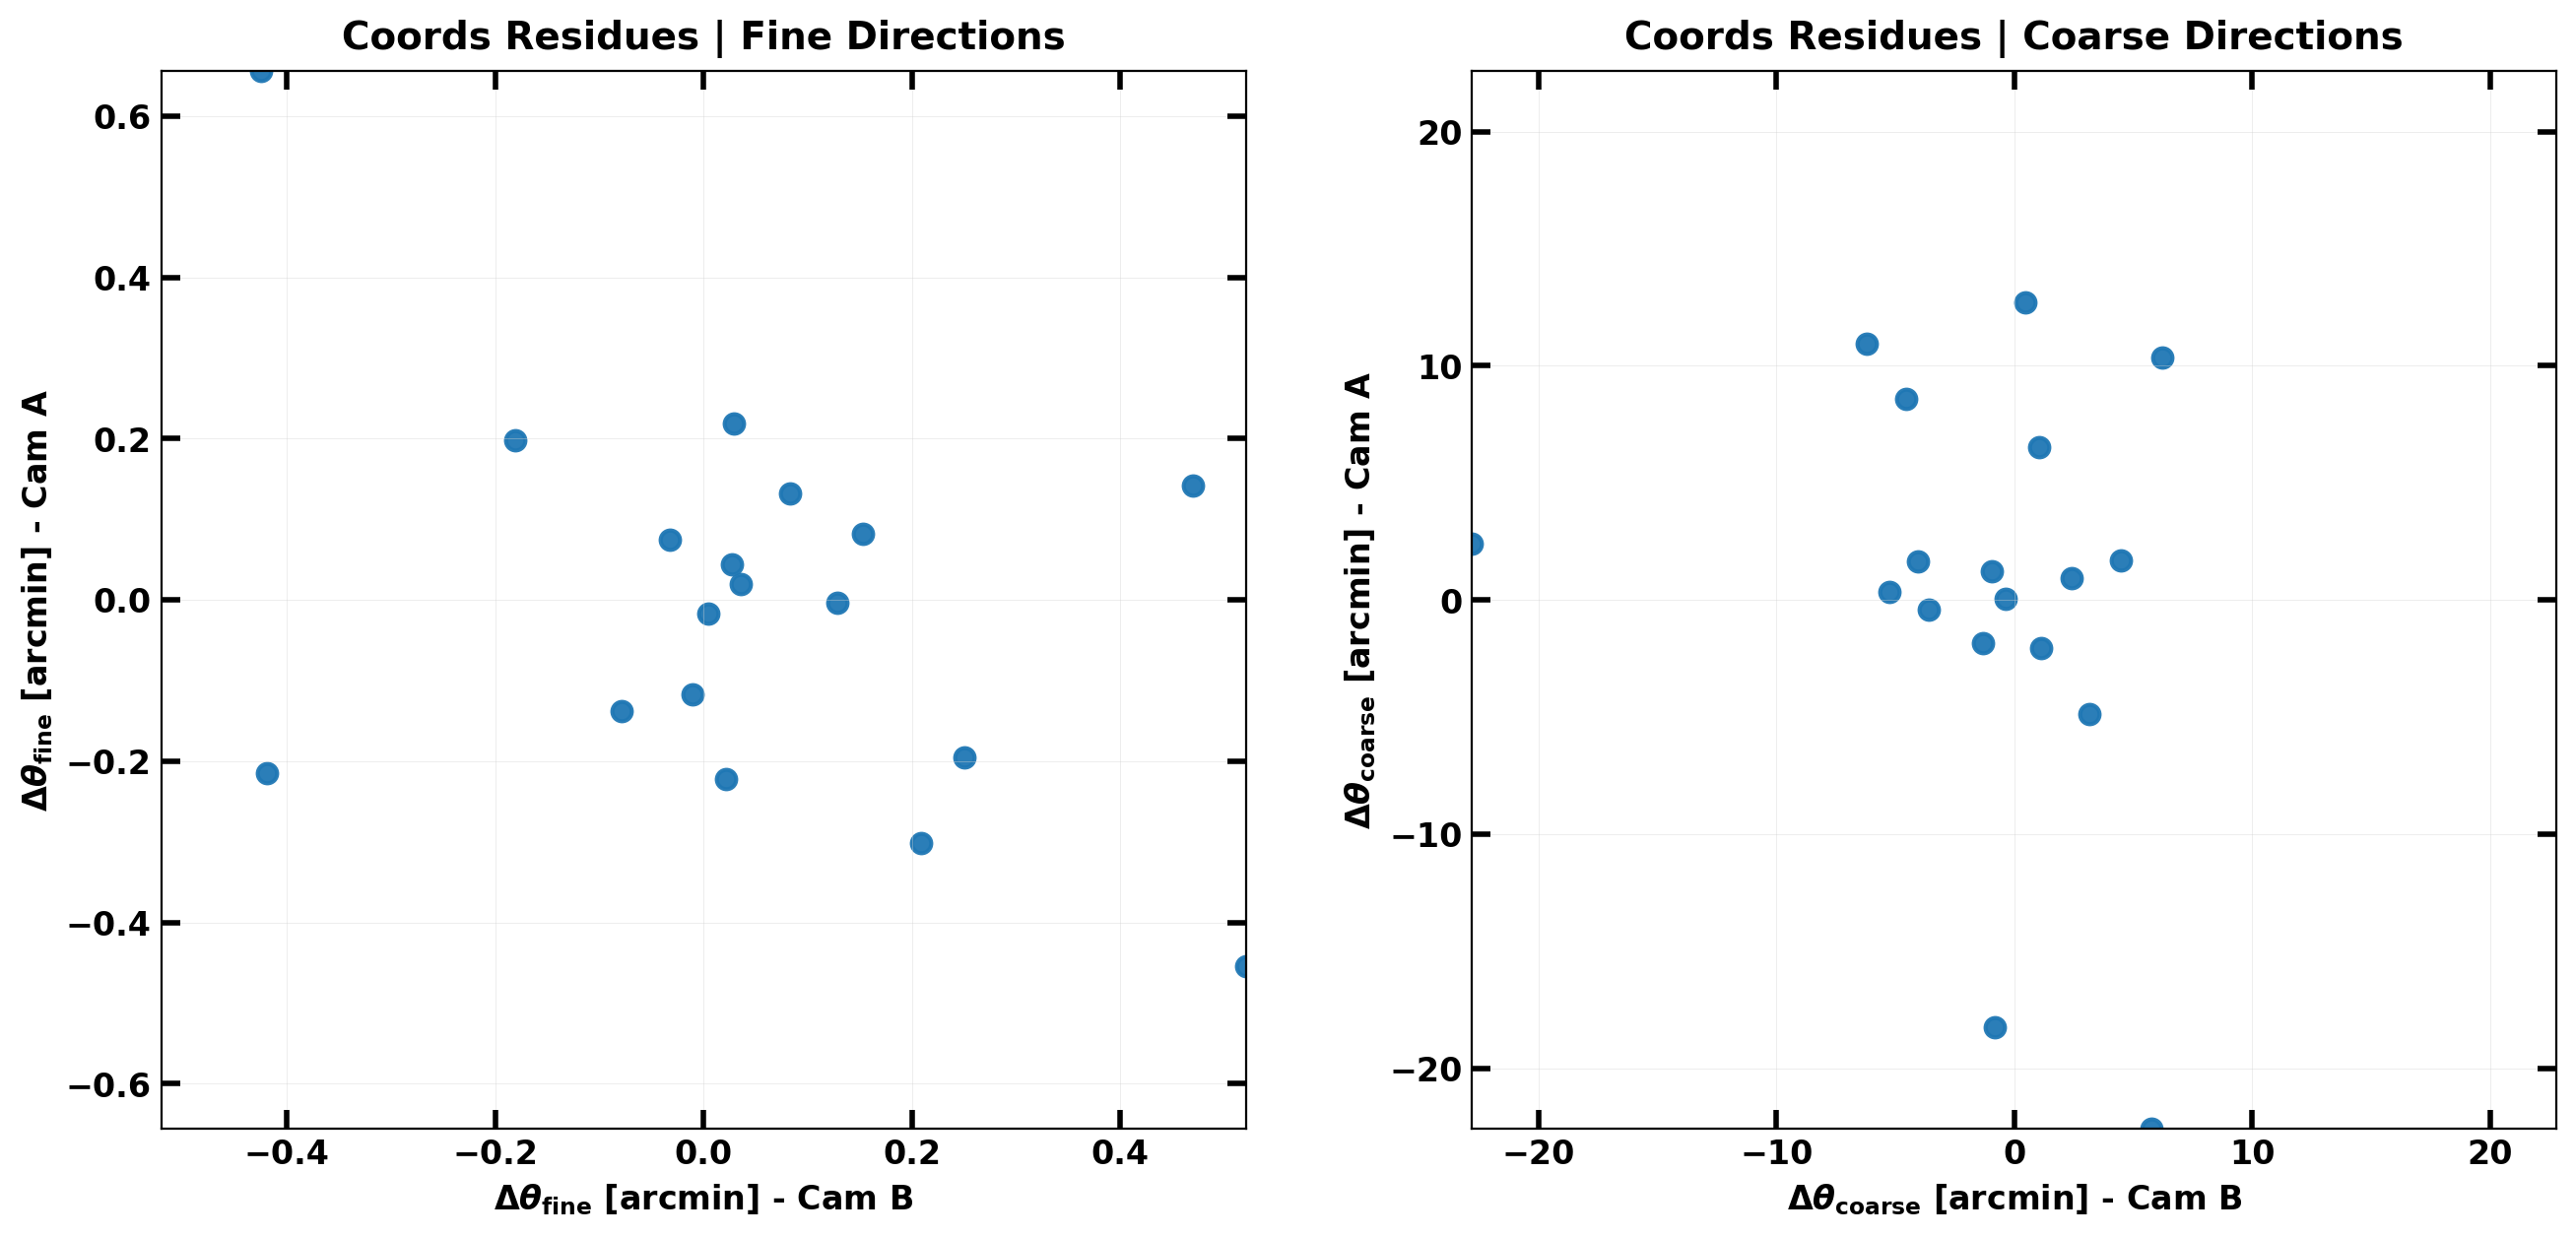

In [14]:
# LEM-X Unit localisation: Src coords residues plot

def get_symlimits(arr: NDArray) -> tuple[float, float]:
    """Returns symmetric `arr` boundary centered around abs max value."""
    m = np.abs(arr).max()
    return -m, m


crdres_fine_A, crdres_coarse_A = get_angularcoords_residues(logA, catA, sdlA, wfm)
crdres_fine_B, crdres_coarse_B = get_angularcoords_residues(logB, catB, sdlB, wfm)

cu_map = get_srcmap_for_unit(logA.log['ID'], logB.log['ID'])
crdres_fine_A, crdres_coarse_A = map(lambda x: x[cu_map.idx_a], (crdres_fine_A, crdres_coarse_A))
crdres_fine_B, crdres_coarse_B = map(lambda x: x[cu_map.idx_b], (crdres_fine_B, crdres_coarse_B))

# crdres_coarse_A, crdres_coarse_B = map(lambda x: x / 60, (crdres_coarse_A, crdres_coarse_B))  # convert to [deg] along coarse

ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=crdres_fine_A,
            title='Coords Residues | Fine Directions',
            x=crdres_fine_B,
            ylabel='$\\Delta\\theta_{\\text{fine}}$ [arcmin] - Cam A',
            xlabel='$\\Delta\\theta_{\\text{fine}}$ [arcmin] - Cam B',
            style='scatter',
            ylim=get_symlimits(crdres_fine_A),
            xlim=get_symlimits(crdres_fine_B),
        ),
        ds.map4plot(
            arrs=crdres_coarse_A,
            title='Coords Residues | Coarse Directions',
            x=crdres_coarse_B,
            ylabel='$\\Delta\\theta_{\\text{coarse}}$ [arcmin] - Cam A',
            xlabel='$\\Delta\\theta_{\\text{coarse}}$ [arcmin] - Cam B',
            style='scatter',
            ylim=get_symlimits(crdres_coarse_A),
            xlim=get_symlimits(crdres_coarse_B),
        ),
    ),
    ncols=2,
    save_to=f'{OUT_RESULTS_PATH}/camUnit_src_coords_res.pdf',
)

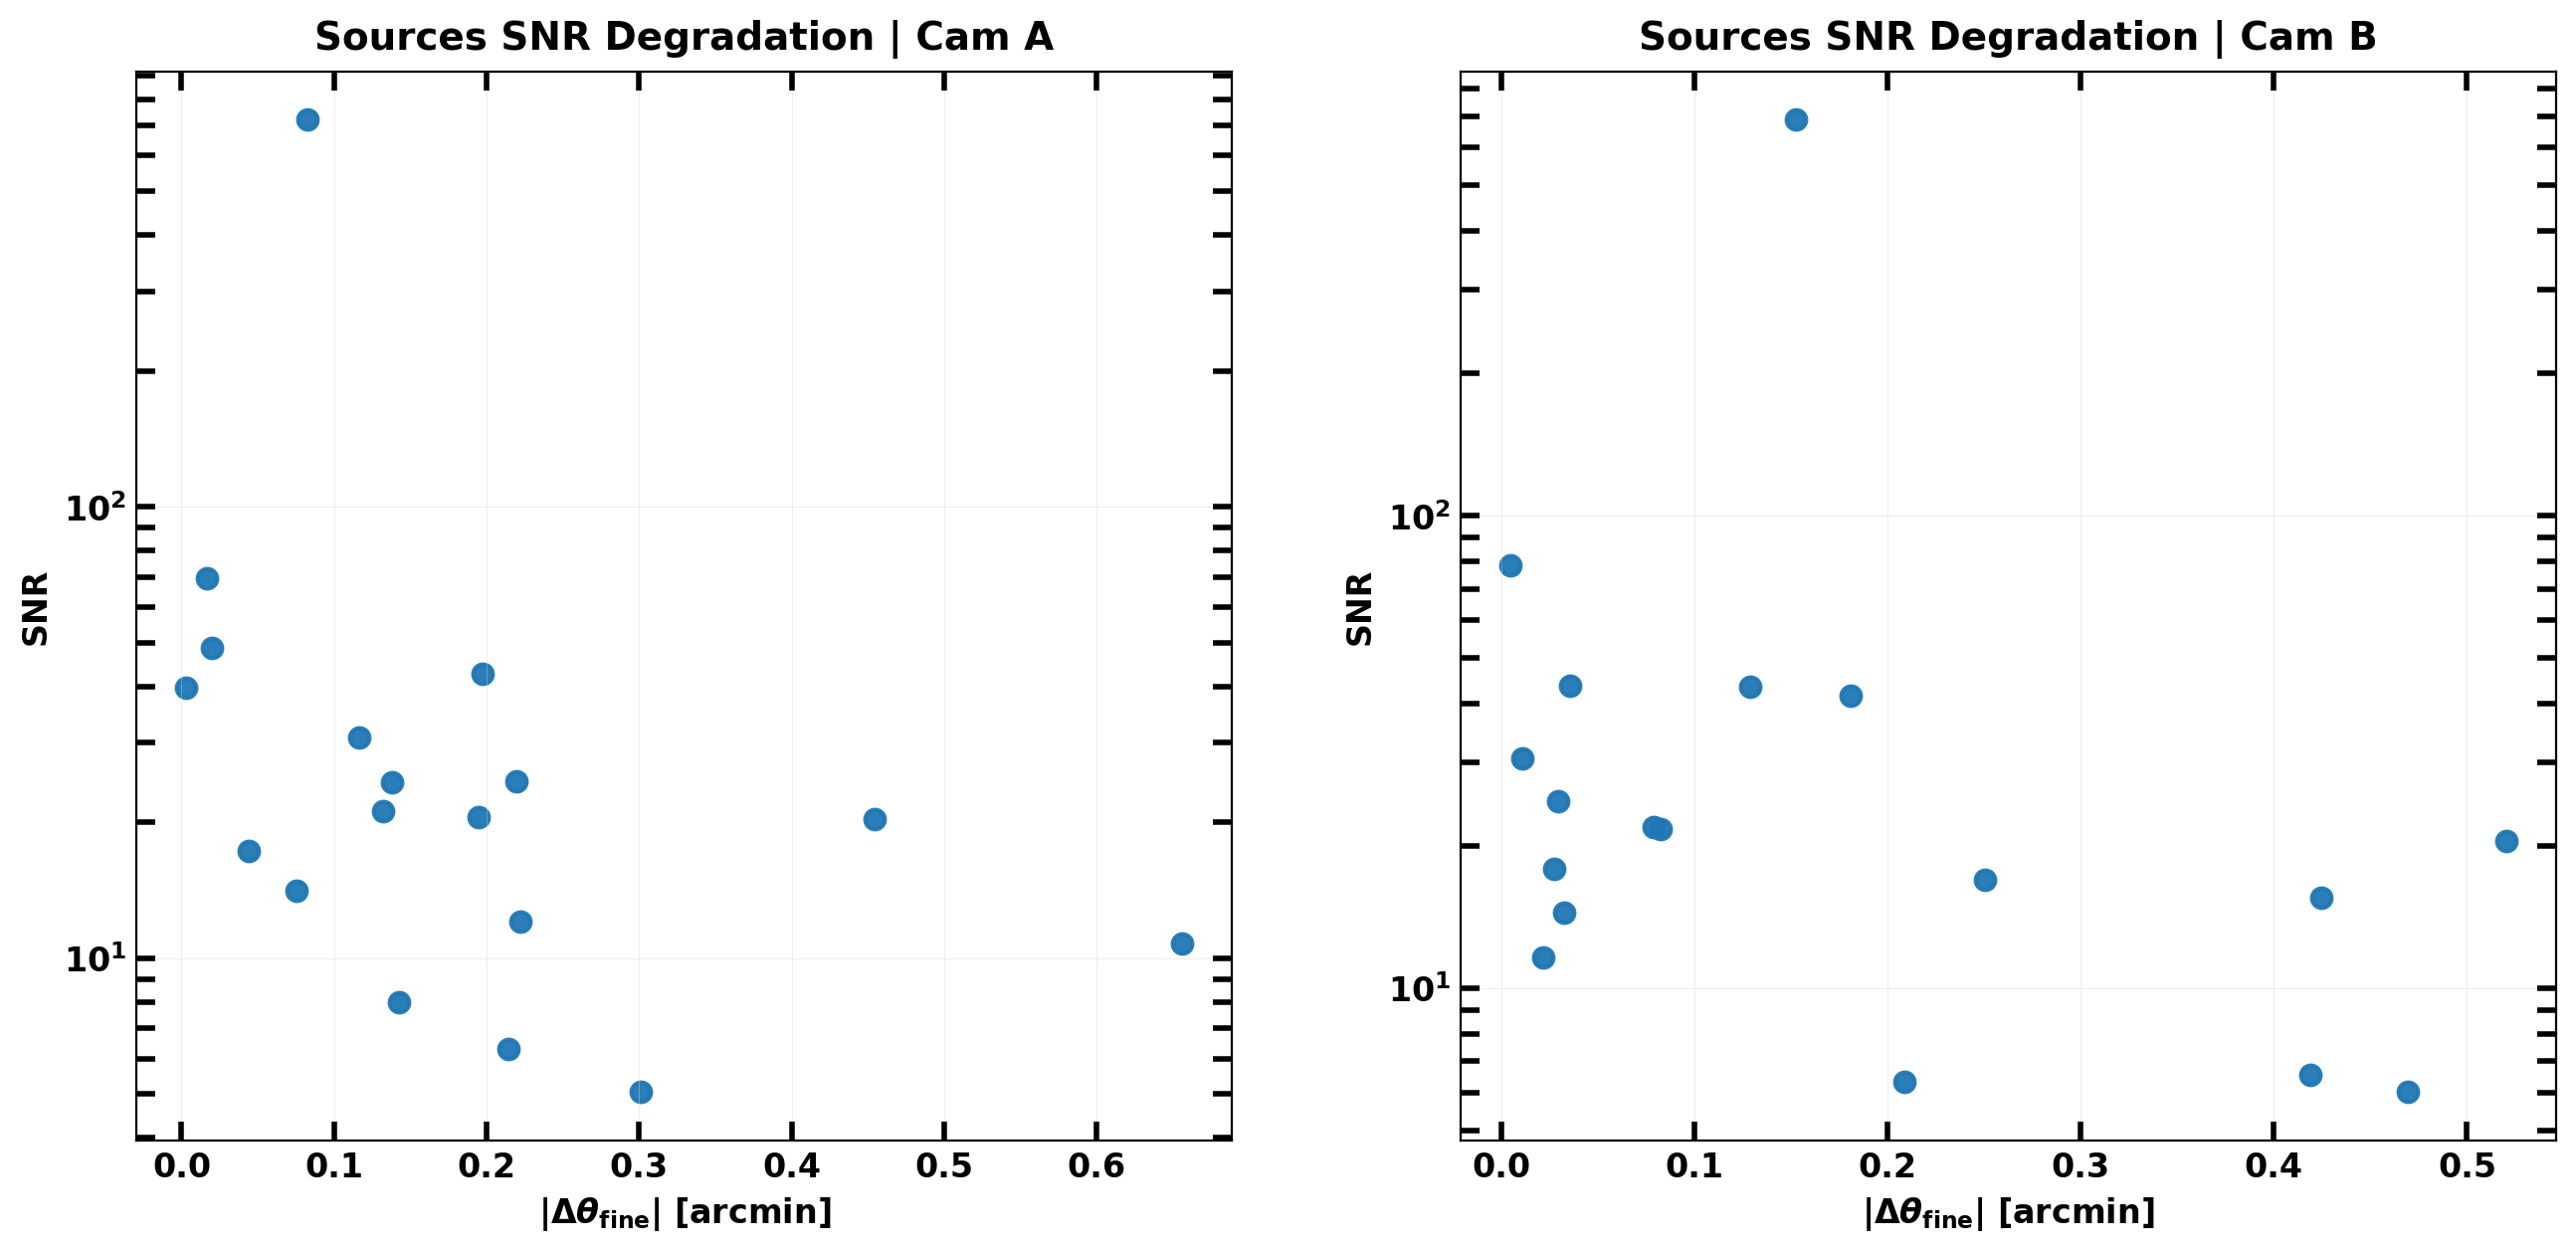

In [15]:
# LEM-X Unit localisation: SNR vs localisation efficiency

snr_A = np.array(logA.log['snr'])[cu_map.idx_a]
snr_B = np.array(logB.log['snr'])[cu_map.idx_b]

ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=snr_A,
            title='Sources SNR Degradation | Cam A',
            x=np.abs(crdres_fine_A),
            ylabel='SNR',
            xlabel='$|\\Delta\\theta_{\\text{fine}}|$ [arcmin]',
            style='scatter',
            yscale='log',
        ),
        ds.map4plot(
            arrs=snr_B,
            title='Sources SNR Degradation | Cam B',
            x=np.abs(crdres_fine_B),
            ylabel='SNR',
            xlabel='$|\\Delta\\theta_{\\text{fine}}|$ [arcmin]',
            style='scatter',
            yscale='log',
        ),
    ),
    ncols=2,
    save_to=f'{OUT_RESULTS_PATH}/srcs_snr_degrad.pdf',
)

### **Sources Statistics**

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


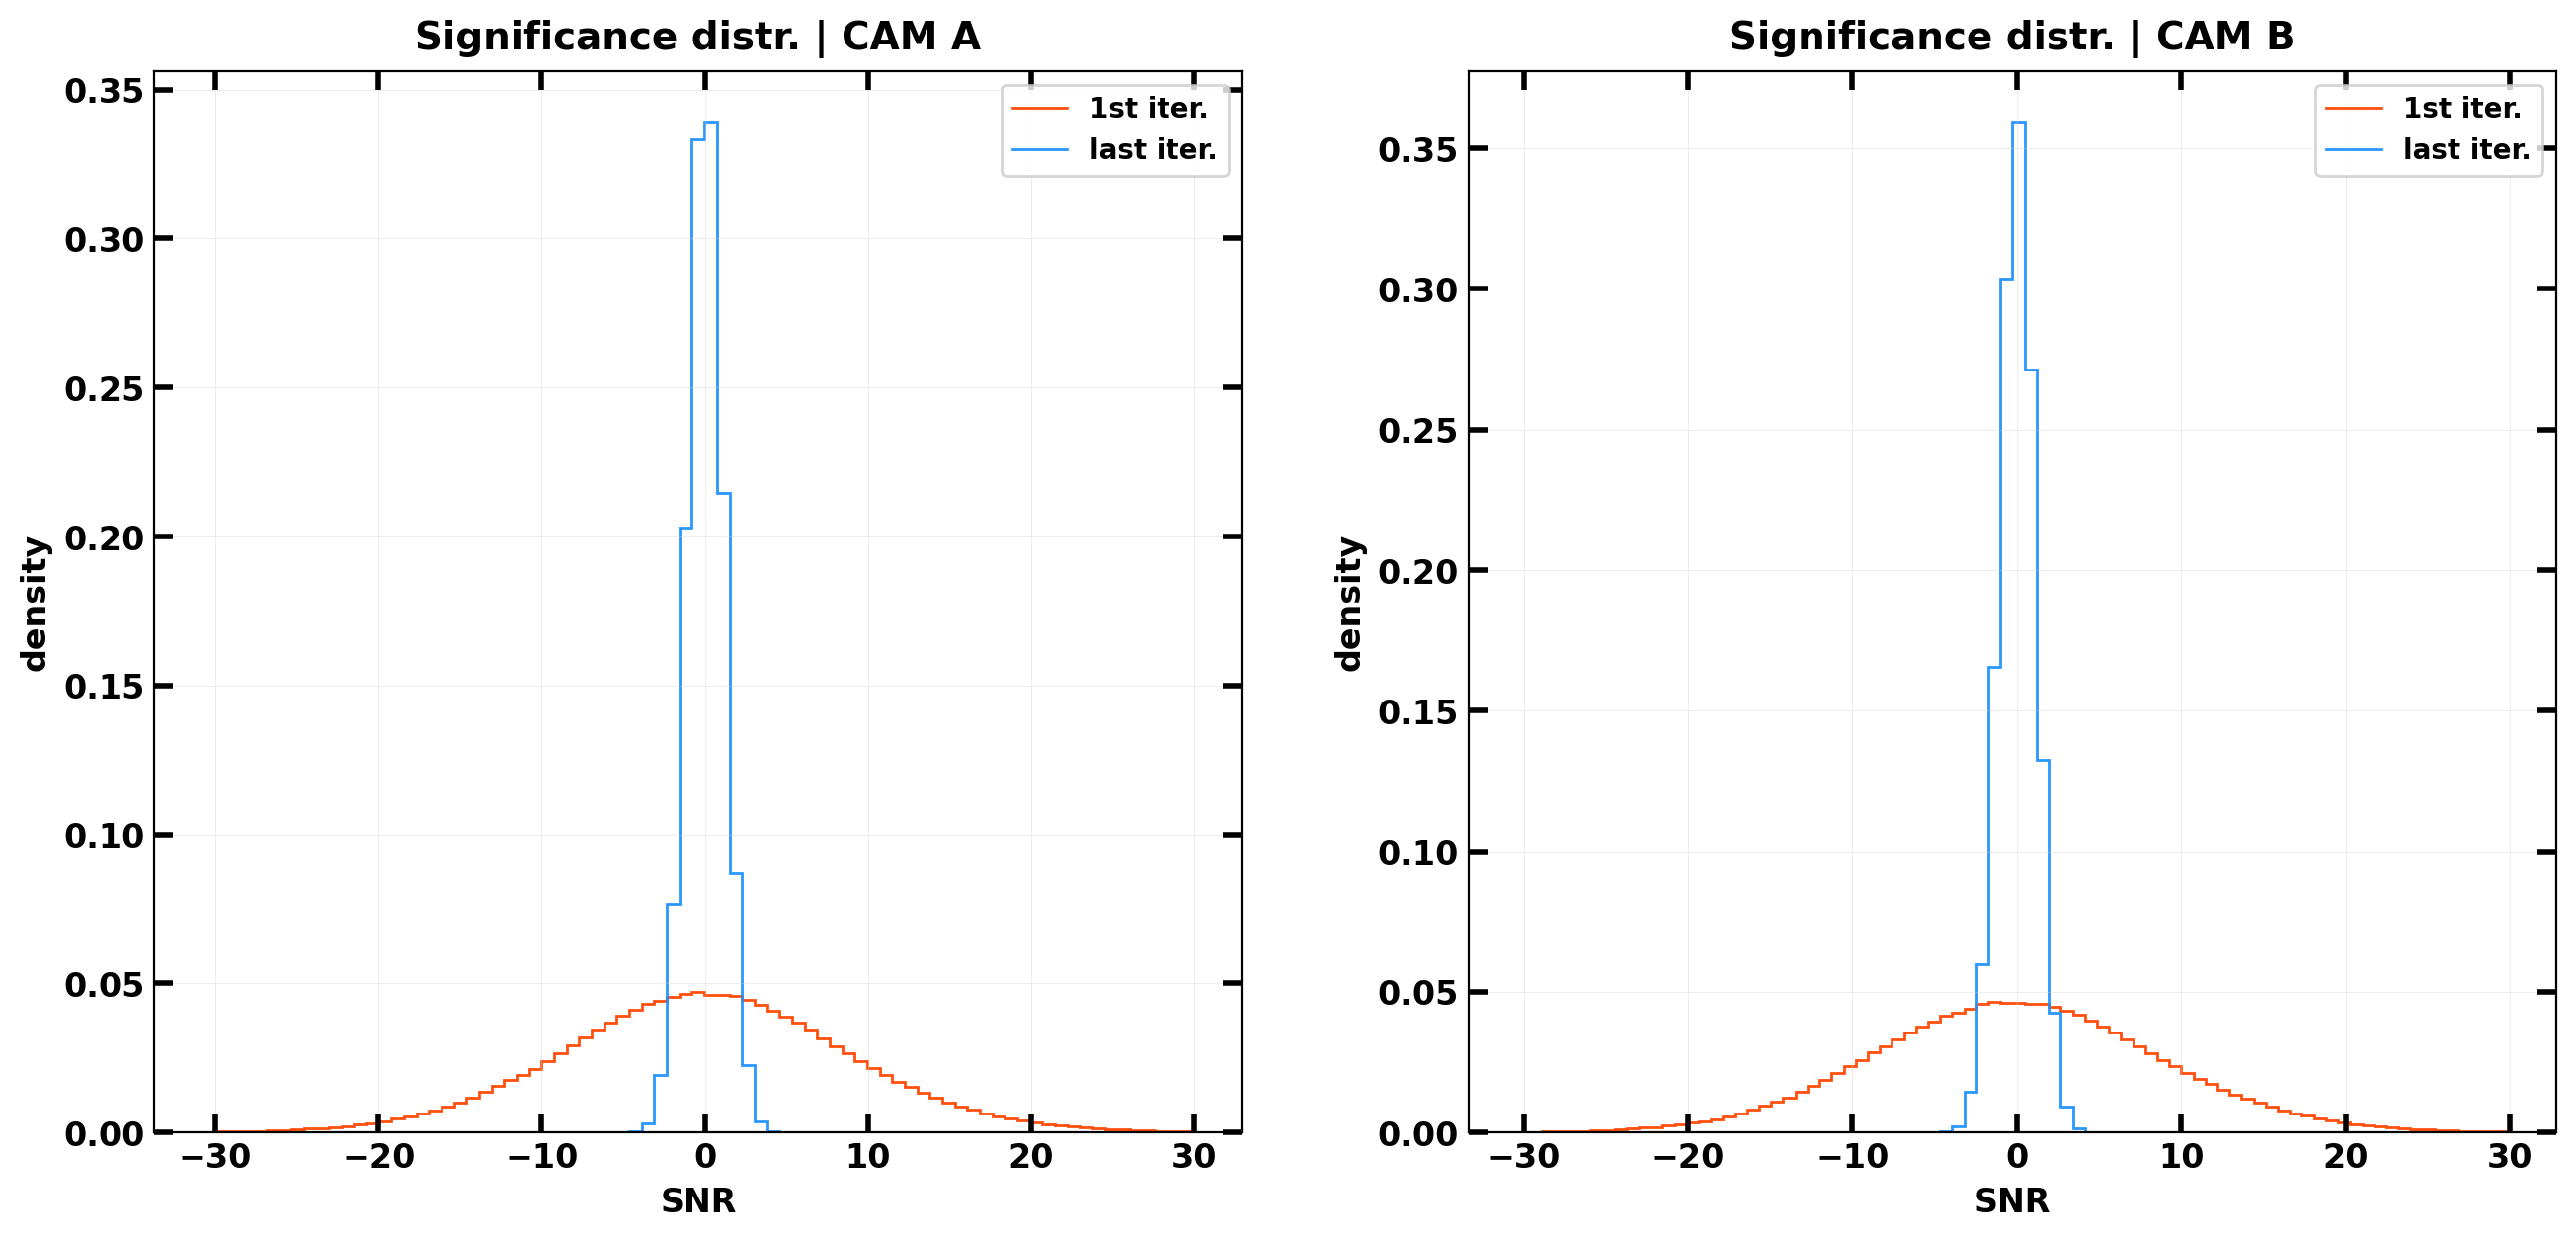

In [16]:
# SNR distr. vs coding noise reduction (true sky --> last IROS iteration)
ycut, xcut = UPS_Y * 30, UPS_X * 20
num_bins = 1000
density = True
distr_lims = (-30, 30)

# - CAMERA A
_, true_skysnr = ds.load_sky(f'{SAVE_PATH}/sky_SIMUL_CAM1A.fits')
_, res_skysnr = ds.load_sky(f'{SAVE_PATH}/skyRES_IROS_CAM1A.fits')

true_skysnr = ds.unframe(true_skysnr, ycut, xcut)
res_skysnr = ds.unframe(res_skysnr, ycut, xcut)

hist_true_skysnr, bins = np.histogram(true_skysnr, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr, bins=bins, density=density)
bins_slice, hist_slice = ds.config_distr_limits(bins, *distr_lims)

dmapA_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. | CAM A',
    xlabel='SNR',
    ylabel='density',
    labels=('1st iter.', 'last iter.'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
)

# - CAMERA B
_, true_skysnr = ds.load_sky(f'{SAVE_PATH}/sky_SIMUL_CAM1B.fits')
_, res_skysnr = ds.load_sky(f'{SAVE_PATH}/skyRES_IROS_CAM1B.fits')

true_skysnr = ds.unframe(true_skysnr, ycut, xcut)
res_skysnr = ds.unframe(res_skysnr, ycut, xcut)

hist_true_skysnr, bins = np.histogram(true_skysnr, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr, bins=bins, density=density)
bins_slice, hist_slice = ds.config_distr_limits(bins, *distr_lims)

dmapB_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. | CAM B',
    xlabel='SNR',
    ylabel='density',
    labels=('1st iter.', 'last iter.'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
)

# - PLOT

ds.plot(
    dmaps=(dmapA_snr, dmapB_snr),
    ncols=2,
    save_to=f'{OUT_RESULTS_PATH}/snr_distr_vs_codnoise.pdf',
)

<br>

<br>

<br>

<br>

## <center>**Source Modelling**<center>

In [17]:
from bloodmoon.mask import count, decode, variance
from bloodmoon.optim import model_sky

detector, _ = count(wfm, sdlA.DLdata)
varmap = variance(wfm, detector)
true_skyA = decode(wfm, detector)

### **PSF Slices**

In [18]:
def custom_slices_plot(
    camera: CodedMaskCamera,
    sky: NDArray | tuple[NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    *,
    title_prefix: str | None = None,
    ylabel: str | None = None,
    ylim_xslice: tuple[Any, Any] | None = None,
    ylim_yslice: tuple[Any, Any] | None = None,
    labels: str | tuple[str | None] | None = None,
    color: str | tuple[str] | None = None,
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots horizontal and vertical slices of 2D data arrays centered at a given position.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    cropped = tuple(
        ds.crop(s, pos, crp, strict=False) for s in (
            (sky,) if isinstance(sky, np.ndarray) else sky
        )
    )
    xslice, yslice = zip(
        *tuple((c[crp[0], :], c[:, crp[1]]) for c in cropped)
    )
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    kws = {
        'ylabel': ylabel or 'counts [ph]',
        'labels': labels,
        'style': 'stairs',
        'color': color,
    }
    dmapx = ds.map4plot(
        arrs=xslice,
        title=f"{title_prefix_}" + "Fine-direction Slice",
        xlabel='$\\theta_{fine}$ [arcmin]',
        x=map(lambda x: dtx * phase(x), xslice),
        ylim=ylim_xslice or (None, None),
        **kws,
    )
    dmapy = ds.map4plot(
        arrs=yslice,
        title=f"{title_prefix_}" + "Coarse-direction Slice",
        xlabel='$\\theta_{coarse}$ [deg]',
        x=map(lambda y: dty * phase(y) / 60, yslice),
        ylim=ylim_yslice or (None, None),
        **kws,
    )
    ds.plot(
        dmaps=(dmapx, dmapy),
        ncols=2,
        save_to=save_to,
        **kwargs,
    )
    return

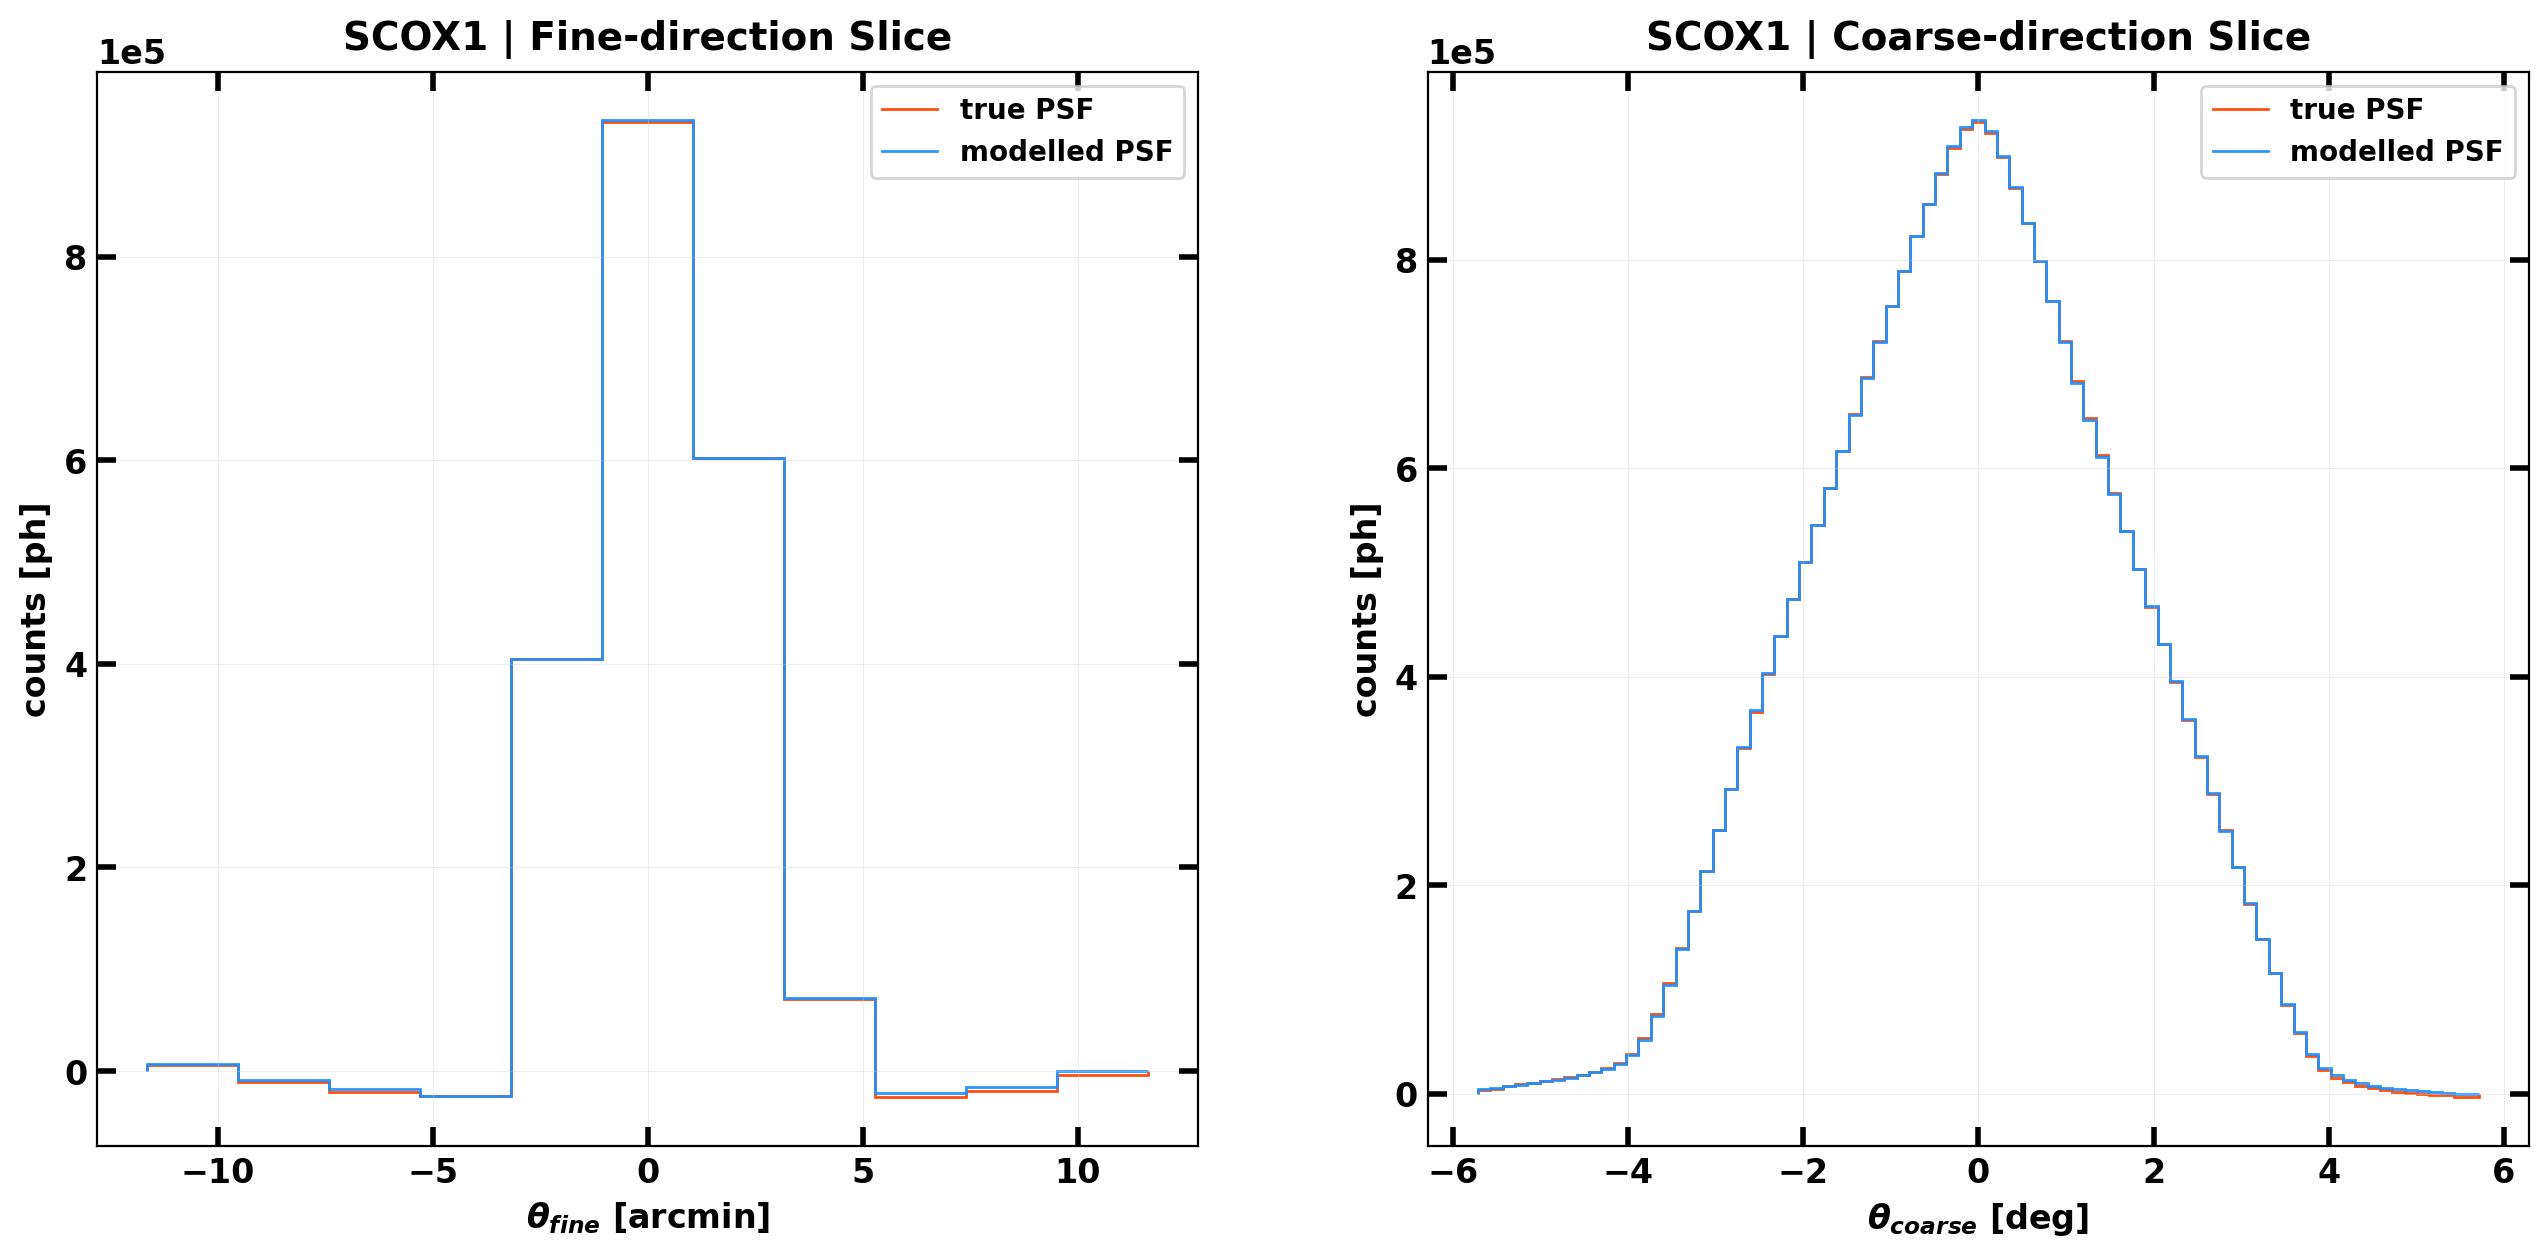

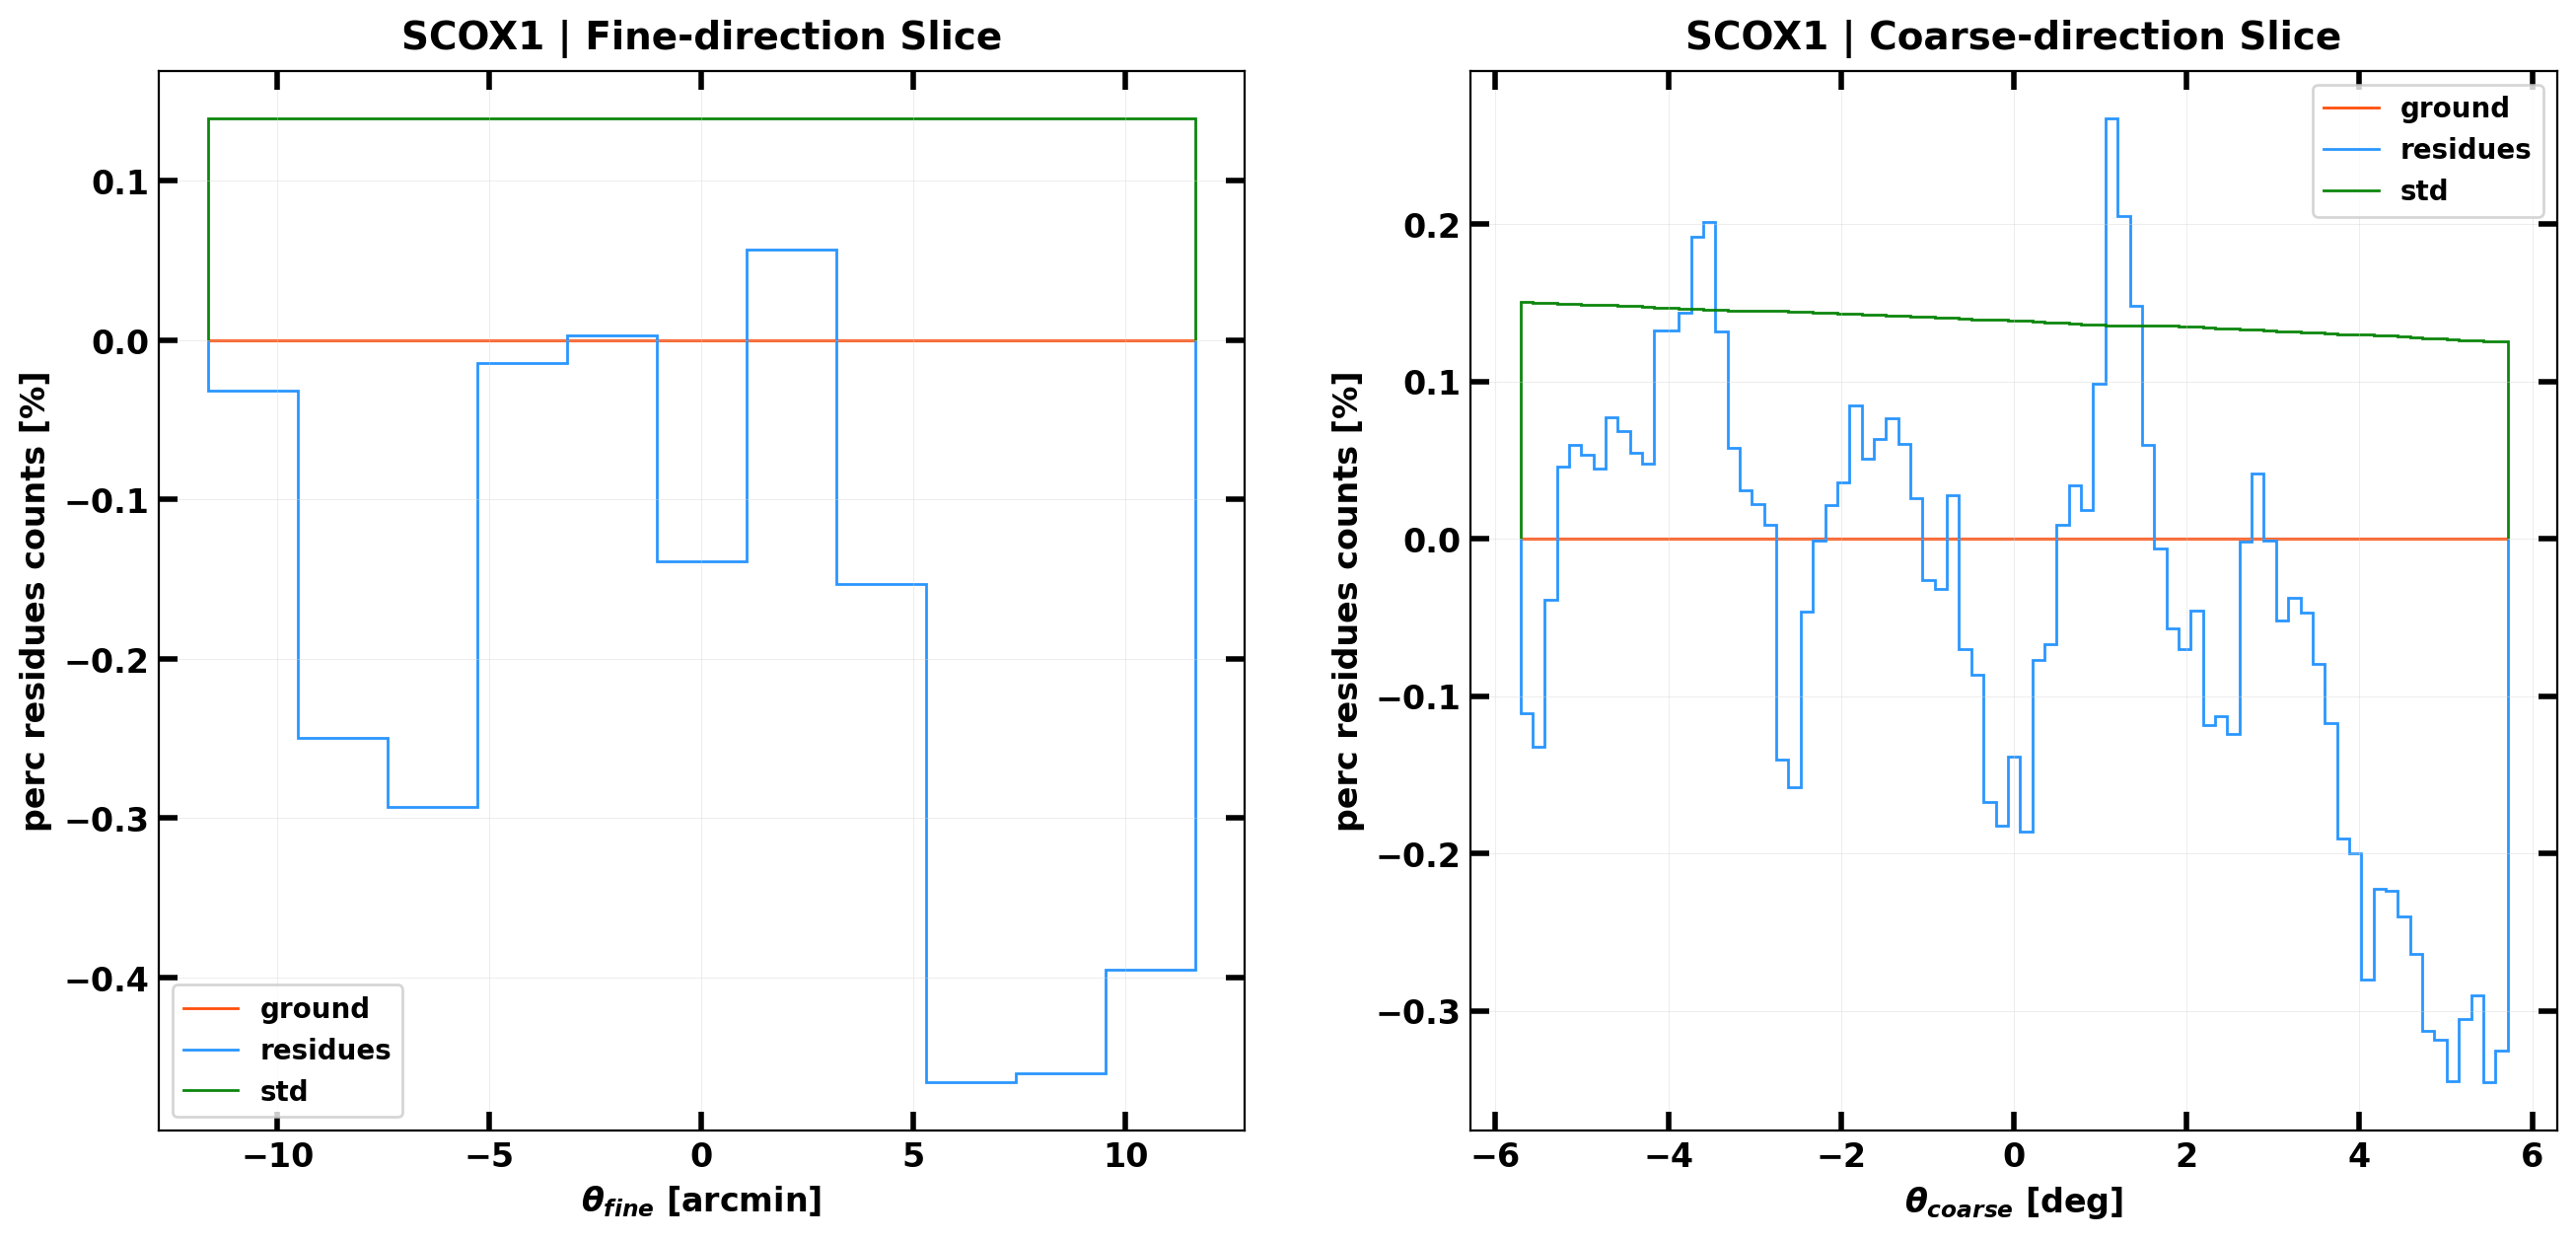

In [23]:
IDX: int = 0   # scox-1
KWS = {
    'pos': (logA.log['y'][IDX], logA.log['x'][IDX]),
    'crp': (40, 5),
    'title_prefix': logA.log['ID'][IDX].upper(),
    'color': ('OrangeRed', 'DodgerBlue', 'Green'),
}
PERC: bool = True

template = model_sky(wfm, logA.log['shift_x'][IDX], logA.log['shift_y'][IDX], logA.log['fluence'][IDX])
residues = true_skyA - template
loc_std = np.sqrt(varmap)

custom_slices_plot(
    camera=wfm,
    sky=(true_skyA, template),
    labels=('true PSF', 'modelled PSF'),
    save_to=f'{OUT_RESULTS_PATH}/psf_slices_{E_min}-{E_max}keV.pdf',
    **KWS,
)
if PERC:
    residues_ = residues * 100 / true_skyA[KWS['pos']]; loc_std_ = loc_std * 100 / true_skyA[KWS['pos']]
else:
    residues_ = residues; loc_std_ = loc_std
custom_slices_plot(
    camera=wfm,
    sky=(np.zeros_like(residues_), residues_, loc_std_),
    labels=('ground', 'residues', 'std'),
    ylabel=r'perc residues counts [%]',
    save_to=f'{OUT_RESULTS_PATH}/psf_slices_res_{E_min}-{E_max}keV.pdf',
    **KWS,
)

### **PSF HeatMaps**

In [20]:
def custom_PSF_hmap(
    camera: CodedMaskCamera,
    psf: NDArray,
    residues: NDArray,
    xticks: NDArray,
    yticks: NDArray,
    title_prefix: str | None = None,
    save_to: str | Path | None = None,
) -> None:
    """
    Plots the true PSF of given source and residues wrt `bm` template from IROS.
    """    
    PLOTPARAMS = export_pltparams()
    n, m = psf.shape
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    _yticks_lbl, _xticks_lbl = dty / 60 * (yticks - n // 2), dtx * (xticks - m // 2)
    yticks_lbl, xticks_lbl = map(lambda arr: [float(f'{a:.1f}') for a in arr], (_yticks_lbl, _xticks_lbl))
    aspect = 2 * KWS['crp'][1] / KWS['crp'][0]
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''

    res_ = residues * 100 / psf[(n - 1) // 2, (m - 1) // 2]
    valres = max(abs(res_.min()), abs(res_.max()))

    dsp = DSPlot(2, 1)
    fig, axs = dsp.config_subplots(ptype='image')
    fig.subplots_adjust(wspace=-1e-1)

    # - IMG axis 0  |  PSF
    dsp.config_labels(axs[0], f'{title_prefix_}PSF', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[0].imshow(psf, origin=PLOTPARAMS['cbar_origin'], cmap='gist_heat', aspect=aspect)
    cbar = fig.colorbar(
        img, ax=axs[0], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'counts [ph]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )

    # - IMG axis 1  |  Residues (true-template)
    dsp.config_labels(axs[1], f'{title_prefix_}Residues', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[1].imshow(
        res_, origin=PLOTPARAMS['cbar_origin'], cmap='viridis', aspect=aspect, vmin=-valres, vmax=valres,
    )
    cbar = fig.colorbar(
        img, ax=axs[1], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'perc residues counts [%]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    
    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(
            which='both', direction='in', width=3, length=5 if 'major' else 2,
        )
        ax.set_yticks(yticks, yticks_lbl)
        ax.set_xticks(xticks, xticks_lbl)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

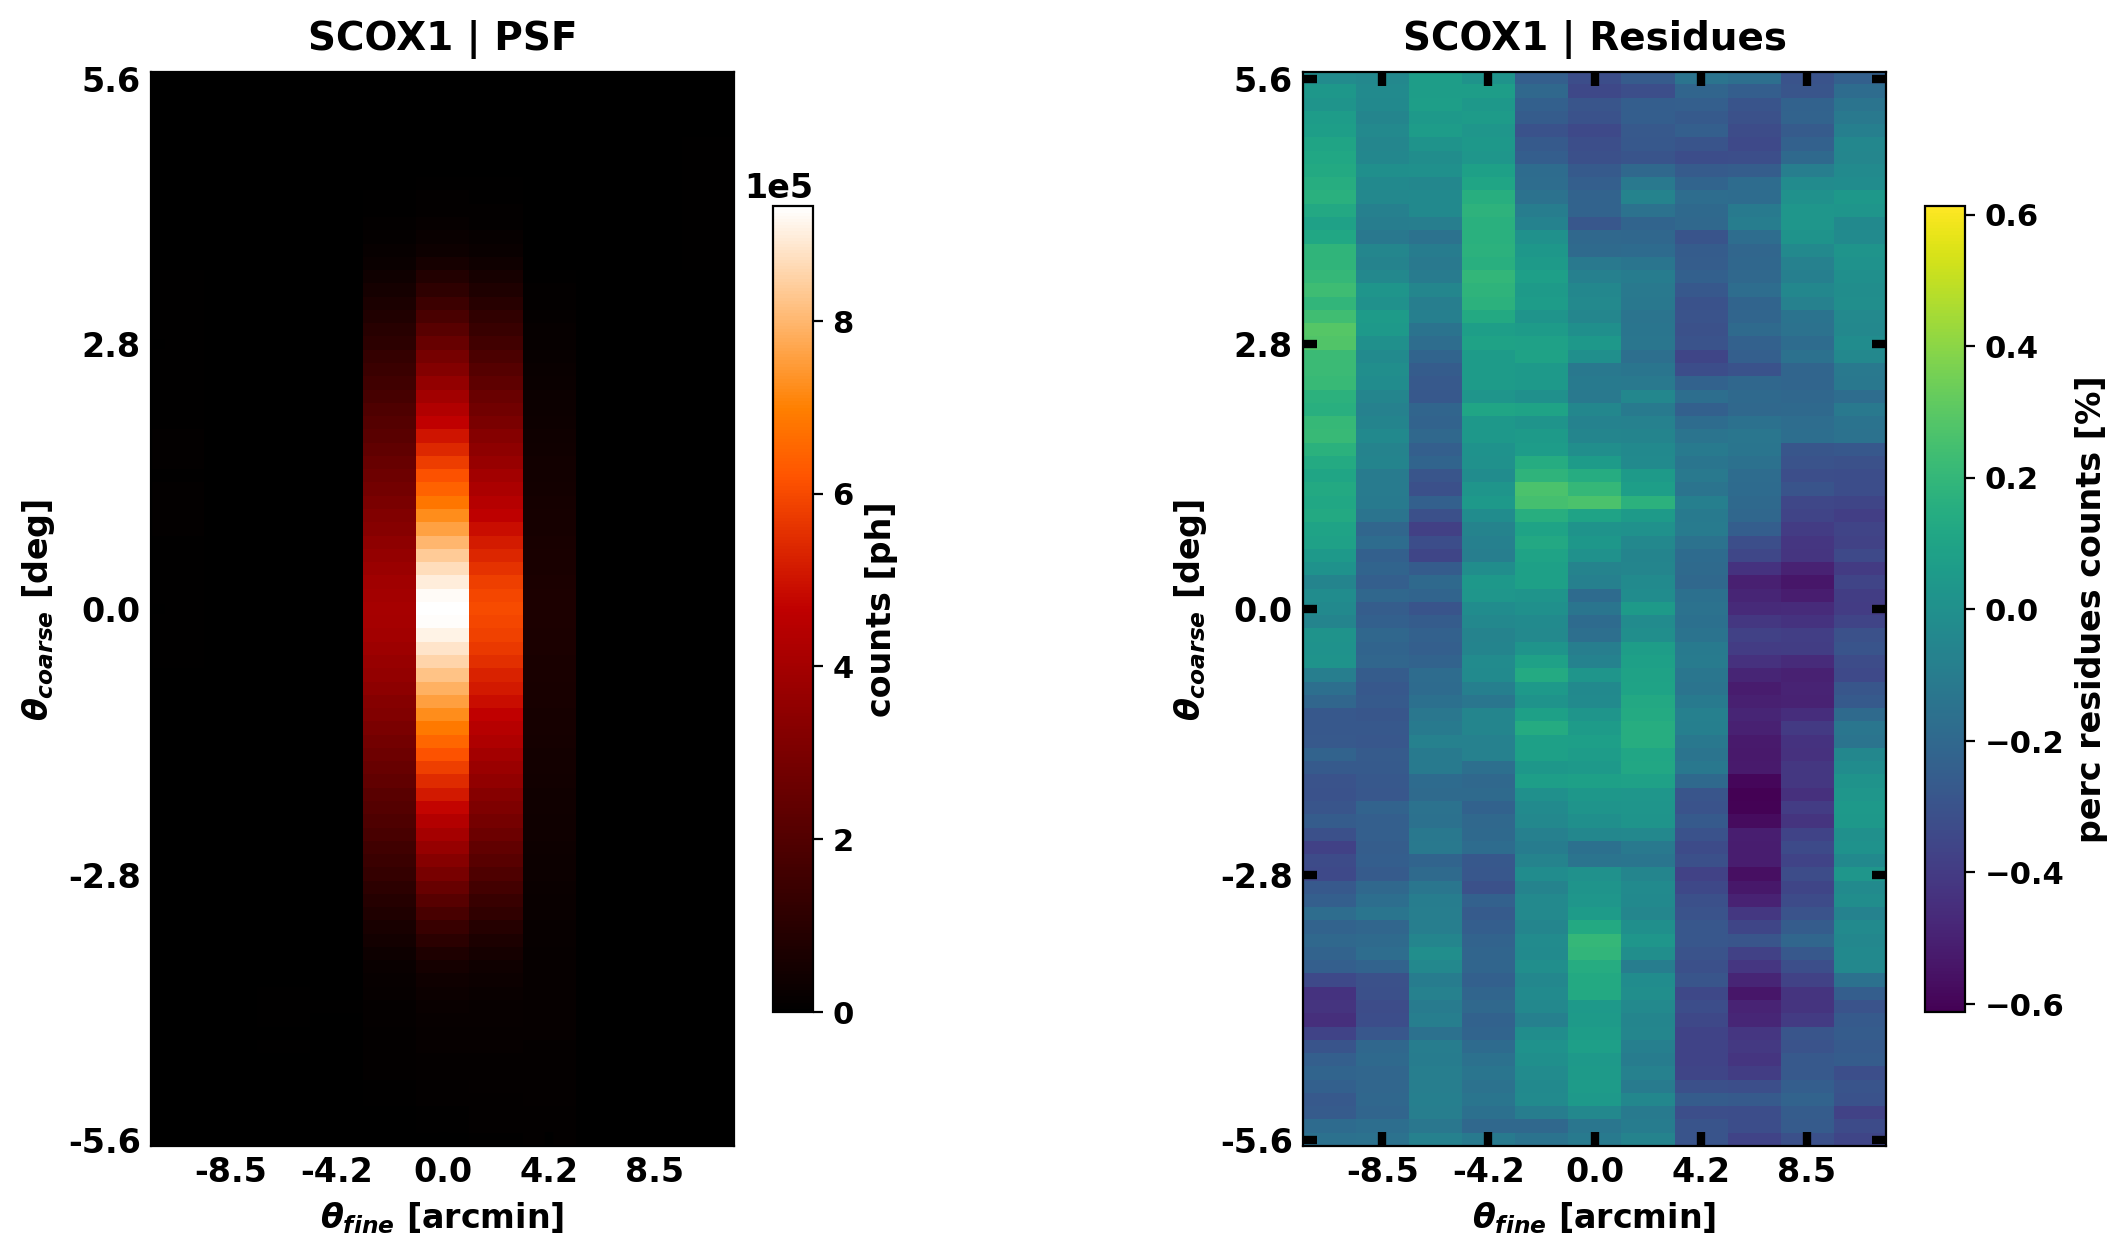

In [21]:
src_psf, src_res = map(lambda x: ds.crop(x, KWS['pos'], KWS['crp']), (true_skyA, residues))

n, m = src_psf.shape
yticks, xticks = np.arange(n)[::20], (np.arange(m)[::2] + 1)[:-1]

custom_PSF_hmap(
    camera=wfm,
    psf=np.clip(src_psf, a_min=0, a_max=src_psf.max()),
    residues=src_res,
    xticks=xticks,
    yticks=yticks,
    title_prefix=KWS['title_prefix'],
    save_to=f'{OUT_RESULTS_PATH}/psfHM_{E_min}-{E_max}keV.pdf'
)